ГЕНЕРАТОР "ЖИЗНЕННОГО ЦИКЛА КЛИЕНТА"

с сгенерированным датасетом

продвинутая версия

1 вариант

Customer Lifecycle Simulator + Knowledge Graph + GraphRAG Testbed

УСТАНОВКА БИБЛИОТЕК

In [31]:
!pip install -q pandas numpy faker

ИМПОРТ БИБЛИОТЕК

In [32]:
import random
import uuid
from datetime import datetime, timedelta

import numpy as np
import pandas as pd

from faker import Faker

fake = Faker("ru_RU")

random.seed(42)
np.random.seed(42)

СПРАВОЧНИКИ

In [33]:
CITIES = [
    "Москва",
    "Санкт-Петербург",
    "Казань",
    "Новосибирск",
    "Екатеринбург"
]

SEGMENTS = [
    "new",
    "regular",
    "premium",
    "risk"
]

PRODUCTS = [
    "Кредитная карта",
    "Дебетовая карта",
    "Потребительский кредит",
    "Страхование",
    "Инвестиционный счет"
]

EMOTIONS = [
    "happy",
    "neutral",
    "frustrated",
    "angry",
    "loyal"
]

PERSONA GENERATOR

Каждый клиент получает полноценный профиль

In [34]:
def generate_customer():

    segment = random.choice(SEGMENTS)

    age = random.randint(18, 70)

    loyalty = round(
        np.random.uniform(0.2, 1.0),
        2
    )

    churn = round(
        np.random.uniform(0.0, 0.8),
        2
    )

    num_products = random.randint(1, 3)

    products = random.sample(
        PRODUCTS,
        num_products
    )

    return {

        "customer_id":
            str(uuid.uuid4()),

        "name":
            fake.name(),

        "city":
            random.choice(CITIES),

        "age":
            age,

        "segment":
            segment,

        "loyalty_score":
            loyalty,

        "churn_risk":
            churn,

        "products":
            products
    }

LIFECYCLE PLANNER

Граф состояний

In [35]:
STATE_GRAPH = {

    "onboarding": {

        "purchase": 0.6,
        "support": 0.2,
        "leave": 0.2
    },

    "purchase": {

        "support": 0.3,
        "complaint": 0.2,
        "repeat_purchase": 0.5
    },

    "support": {

        "complaint": 0.3,
        "repeat_purchase": 0.4,
        "resolved": 0.3
    },

    "complaint": {

        "retention": 0.5,
        "leave": 0.3,
        "resolved": 0.2
    },

    "retention": {

        "repeat_purchase": 0.5,
        "leave": 0.5
    },

    "repeat_purchase": {

        "support": 0.2,
        "complaint": 0.2,
        "resolved": 0.6
    }
}

ГЕНЕРАТОР ЖИЗНЕННОГО ЦИКЛА

У каждого клиента свой путь

In [36]:
def next_state(current):

    transitions = STATE_GRAPH[current]

    states = list(
        transitions.keys()
    )

    probs = list(
        transitions.values()
    )

    return np.random.choice(
        states,
        p=probs
    )


def generate_lifecycle():

    current = "onboarding"

    path = [current]

    for _ in range(
        random.randint(5, 8)
    ):

        if current not in STATE_GRAPH:
            break

        current = next_state(current)

        path.append(current)

        if current == "leave":
            break

    return path

ЭМОЦИОНАЛЬНАЯ МОДЕЛЬ

In [37]:
EMOTION_MAP = {

    "onboarding":
        "neutral",

    "purchase":
        "happy",

    "support":
        "frustrated",

    "complaint":
        "angry",

    "retention":
        "neutral",

    "repeat_purchase":
        "loyal",

    "resolved":
        "happy",

    "leave":
        "angry"
}

ГЕНЕРАЦИЯ СОБЫТИЙ

Создаётся полный журнал жизненного цикла

In [38]:
def generate_events(customer):

    rows = []

    current_date = datetime(
        2025,
        1,
        1
    )

    lifecycle = generate_lifecycle()

    previous_ticket = None

    for order, state in enumerate(
        lifecycle,
        start=1
    ):

        ticket_id = str(uuid.uuid4())

        current_date += timedelta(
            days=random.randint(10, 40)
        )

        product = random.choice(
            customer["products"]
        )

        rows.append({

            "customer_id":
                customer["customer_id"],

            "customer_name":
                customer["name"],

            "city":
                customer["city"],

            "segment":
                customer["segment"],

            "age":
                customer["age"],

            "loyalty_score":
                customer[
                    "loyalty_score"
                ],

            "churn_risk":
                customer[
                    "churn_risk"
                ],

            "ticket_id":
                ticket_id,

            "previous_ticket":
                previous_ticket,

            "state":
                state,

            "emotion":
                EMOTION_MAP[state],

            "product":
                product,

            "date":
                current_date
        })

        previous_ticket = ticket_id

    return rows

СОЗДАНИЕ (ГЕНЕРАЦИЯ) ДАТАСЕТА

In [39]:
all_events = []

NUM_CUSTOMERS = 100

for _ in range(
    NUM_CUSTOMERS
):

    customer = generate_customer()

    events = generate_events(
        customer
    )

    all_events.extend(events)

events_df = pd.DataFrame(
    all_events
)

events_df.head()

,customer_id,customer_name,city,segment,age,loyalty_score,churn_risk,ticket_id,previous_ticket,state,emotion,product,date
0,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01
1,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,a7b53133-4389-4b9f-a661-23a2b84ae94a,48a5b45f-8836-414d-af5a-f7c9f1c75a95,support,frustrated,Кредитная карта,2025-03-11
2,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,d122f932-0509-4e32-a2ea-dad9f818b197,a7b53133-4389-4b9f-a661-23a2b84ae94a,repeat_purchase,loyal,Кредитная карта,2025-03-23
3,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,6f53761d-c682-4cff-a484-16fcda06204e,d122f932-0509-4e32-a2ea-dad9f818b197,support,frustrated,Потребительский кредит,2025-04-15
4,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,708923c6-ae4e-4379-a352-cd115f57de87,6f53761d-c682-4cff-a484-16fcda06204e,complaint,angry,Потребительский кредит,2025-04-25


ПРОВЕРКА РЕЗУЛЬТАТА

In [40]:
print(
    "Customers:",
    events_df.customer_id.nunique()
)

print(
    "Events:",
    len(events_df)
)

events_df.state.value_counts()

Customers: 100
Events: 448


,count
state,
onboarding,100
support,62
repeat_purchase,59
resolved,57
purchase,55
complaint,48
leave,41
retention,26


In [41]:
events_df

,customer_id,customer_name,city,segment,age,loyalty_score,churn_risk,ticket_id,previous_ticket,state,emotion,product,date
0,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.50,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01
1,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.50,0.76,a7b53133-4389-4b9f-a661-23a2b84ae94a,48a5b45f-8836-414d-af5a-f7c9f1c75a95,support,frustrated,Кредитная карта,2025-03-11
2,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.50,0.76,d122f932-0509-4e32-a2ea-dad9f818b197,a7b53133-4389-4b9f-a661-23a2b84ae94a,repeat_purchase,loyal,Кредитная карта,2025-03-23
3,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.50,0.76,6f53761d-c682-4cff-a484-16fcda06204e,d122f932-0509-4e32-a2ea-dad9f818b197,support,frustrated,Потребительский кредит,2025-04-15
4,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.50,0.76,708923c6-ae4e-4379-a352-cd115f57de87,6f53761d-c682-4cff-a484-16fcda06204e,complaint,angry,Потребительский кредит,2025-04-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,515b6295-8730-4b3c-8d62-e8a0daae025a,Селиверстова Елизавета Вадимовна,Новосибирск,premium,28,0.68,0.18,e3c23253-1b17-4053-811a-8b5371a08013,cdbde2c7-714f-43af-9d03-0c5d8e58df1c,support,frustrated,Потребительский кредит,2025-02-15
444,515b6295-8730-4b3c-8d62-e8a0daae025a,Селиверстова Елизавета Вадимовна,Новосибирск,premium,28,0.68,0.18,8c6abc87-248d-4c35-9221-3d5ec7dd071b,e3c23253-1b17-4053-811a-8b5371a08013,repeat_purchase,loyal,Страхование,2025-03-13
445,515b6295-8730-4b3c-8d62-e8a0daae025a,Селиверстова Елизавета Вадимовна,Новосибирск,premium,28,0.68,0.18,93f0b6a3-b188-40c0-9c85-8fce7df913db,8c6abc87-248d-4c35-9221-3d5ec7dd071b,complaint,angry,Потребительский кредит,2025-04-04
446,515b6295-8730-4b3c-8d62-e8a0daae025a,Селиверстова Елизавета Вадимовна,Новосибирск,premium,28,0.68,0.18,433ae5d6-01be-4004-9cd6-14eed678ed1c,93f0b6a3-b188-40c0-9c85-8fce7df913db,retention,neutral,Потребительский кредит,2025-05-07


ШАБЛОНЫ ДИАЛОГОВ

Для каждого состояния - реалистичные диалоги

In [42]:
DIALOG_TEMPLATES = {

    "onboarding": [
        (
            "Здравствуйте, хочу узнать о ваших услугах.",
            "С удовольствием расскажу."
        ),
        (
            "Я новый клиент.",
            "Добро пожаловать."
        )
    ],

    "purchase": [
        (
            "Хочу оформить продукт.",
            "Помогу оформить заявку."
        ),
        (
            "Интересует покупка.",
            "Расскажу об условиях."
        )
    ],

    "support": [
        (
            "Возник вопрос по продукту.",
            "Сейчас помогу."
        ),
        (
            "Нужна консультация.",
            "Уточняю информацию."
        )
    ],

    "complaint": [
        (
            "Хочу оставить жалобу.",
            "Приносим извинения."
        ),
        (
            "Недоволен обслуживанием.",
            "Зафиксировал обращение."
        )
    ],

    "retention": [
        (
            "Думаю отказаться от услуг.",
            "Можем предложить бонус."
        )
    ],

    "repeat_purchase": [
        (
            "Хочу оформить ещё один продукт.",
            "Есть интересные предложения."
        )
    ],

    "resolved": [
        (
            "Спасибо, вопрос решён.",
            "Рады помочь."
        )
    ],

    "leave": [
        (
            "Планирую закрыть счёт.",
            "Сожалеем о вашем решении."
        )
    ]
}

ГЕНЕРАЦИЯ СООБЩЕНИЙ

Каждое событие превращаем в полноценный диалог

In [43]:
dialog_rows = []

for _, event in events_df.iterrows():

    turns = random.randint(3, 5)

    template = random.choice(
        DIALOG_TEMPLATES[event["state"]]
    )

    for turn in range(turns):

        client_msg = template[0]
        agent_msg = template[1]

        dialog_rows.append({

            **event.to_dict(),

            "message_id":
                str(uuid.uuid4()),

            "speaker":
                "client",

            "text":
                client_msg
        })

        dialog_rows.append({

            **event.to_dict(),

            "message_id":
                str(uuid.uuid4()),

            "speaker":
                "agent",

            "text":
                agent_msg
        })

dialogs_df = pd.DataFrame(
    dialog_rows
)

dialogs_df.head()

,customer_id,customer_name,city,segment,age,loyalty_score,churn_risk,ticket_id,previous_ticket,state,emotion,product,date,message_id,speaker,text
0,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01,fd861253-0385-4445-931a-21a98f2e2892,client,"Здравствуйте, хочу узнать о ваших услугах."
1,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01,71b77243-9878-4570-a236-840f7db458f7,agent,С удовольствием расскажу.
2,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01,efa3c082-4459-4bb2-9c23-089998c8c85b,client,"Здравствуйте, хочу узнать о ваших услугах."
3,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01,db59436f-bbd8-43bc-b63d-8f0329df704e,agent,С удовольствием расскажу.
4,be9d9139-00e4-46a4-8eb5-ce9d30b3fccf,Данила Валерианович Титов,Санкт-Петербург,new,19,0.5,0.76,48a5b45f-8836-414d-af5a-f7c9f1c75a95,None,onboarding,neutral,Кредитная карта,2025-02-01,be0af142-e9eb-48ef-9a9d-e356b8be652b,client,"Здравствуйте, хочу узнать о ваших услугах."


CONSISTENCY CHECKER

Проверка логики жизненного цикла

In [44]:
def validate_customer(group):

    states = list(group.state)

    if (
        "complaint" in states
        and
        "purchase" not in states
    ):
        return False

    return True


valid_customers = []

for cid, grp in events_df.groupby(
    "customer_id"
):

    if validate_customer(grp):
        valid_customers.append(cid)

dialogs_df = dialogs_df[
    dialogs_df.customer_id.isin(
        valid_customers
    )
]

ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ

Простейший NER

In [45]:
ENTITY_RULES = {

    "Contract": [
        "договор"
    ],

    "Complaint": [
        "жалоб"
    ],

    "Application": [
        "заявк"
    ],

    "Product": [
        "продукт"
    ]
}

Функция

In [46]:
def extract_entities(text):

    entities = []

    text = text.lower()

    for entity, patterns in ENTITY_RULES.items():

        for p in patterns:

            if p in text:

                entities.append(
                    entity
                )

    return entities

In [47]:
dialogs_df["entities"] = (
    dialogs_df["text"]
    .apply(extract_entities)
)

NLP

In [48]:
!pip install -q sentence-transformers bertopic faiss-cpu

Эмбеддинги

In [49]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

texts = dialogs_df[
    "text"
].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

BERTopic

In [50]:
from bertopic import BERTopic

topic_model = BERTopic(
    language="multilingual"
)

topics, probs = topic_model.fit_transform(
    texts
)

dialogs_df["topic"] = topics

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

FAISS

In [51]:
import faiss
import numpy as np

dim = embeddings.shape[1]

index = faiss.IndexFlatL2(dim)

index.add(
    np.array(embeddings)
    .astype("float32")
)

SEMANTIC SEARCH

In [52]:
def semantic_search(
    query,
    k=5
):

    q = model.encode([query])

    D, I = index.search(
        np.array(q)
        .astype("float32"),
        k
    )

    return dialogs_df.iloc[
        I[0]
    ]

KNOWLEDGE GRAPH

Создание расширенного графа

In [53]:
import networkx as nx

G = nx.DiGraph()

УЗЛЫ И СВЯЗИ

In [54]:
for _, row in dialogs_df.iterrows():

    customer = row.customer_id
    ticket = row.ticket_id
    message = row.message_id

    G.add_node(
        customer,
        type="Customer"
    )

    G.add_node(
        ticket,
        type="Ticket"
    )

    G.add_node(
        message,
        type="Message"
    )

    G.add_node(
        row.product,
        type="Product"
    )

    G.add_node(
        row.city,
        type="City"
    )

    G.add_node(
        row.segment,
        type="Segment"
    )

    G.add_node(
        row.emotion,
        type="Emotion"
    )

    G.add_node(
        str(row.topic),
        type="Topic"
    )

    G.add_edge(
        customer,
        ticket,
        rel="CREATED"
    )

    G.add_edge(
        ticket,
        message,
        rel="HAS_MESSAGE"
    )

    G.add_edge(
        customer,
        row.city,
        rel="LIVES_IN"
    )

    G.add_edge(
        customer,
        row.segment,
        rel="BELONGS_TO"
    )

    G.add_edge(
        ticket,
        row.product,
        rel="ABOUT_PRODUCT"
    )

    G.add_edge(
        ticket,
        row.emotion,
        rel="HAS_EMOTION"
    )

    G.add_edge(
        ticket,
        str(row.topic),
        rel="HAS_TOPIC"
    )

    for entity in row.entities:

        G.add_node(
            entity,
            type="Entity"
        )

        G.add_edge(
            message,
            entity,
            rel="MENTIONS"
        )

GraphRAG Retrieval

In [55]:
def graph_rag_search(
    query,
    top_k=3
):

    results = semantic_search(
        query,
        top_k
    )

    context = []

    for _, row in results.iterrows():

        context.append(
            row.text
        )

        ticket = row.ticket_id

        neighbors = list(
            G.neighbors(ticket)
        )

        context.extend(
            map(str, neighbors)
        )

    return "\n".join(
        sorted(
            set(context)
        )
    )

Проверка

In [56]:
print(
    graph_rag_search(
        "жалоба клиента"
    )
)

20
20828de4-6c2d-46b8-a93a-8618c7908fe9
21
22b100f7-71a8-479a-aff6-0d3c8f8f92c4
2b81c6d4-11fe-4ef5-be11-c4f477dd5553
33afa631-ed29-4947-aa2f-265fce42a3cb
5f3fa7a4-142f-467b-97de-d739046fbfc6
89e76e3e-de48-4905-8121-97799683c7cc
96a97d62-527f-48c0-99dc-d058693604d2
<bound method Series.prod of customer_id        f100d50a-5e4b-4ca2-9890-5cc8ee010625
customer_name                Агафья Алексеевна Андреева
city                                        Новосибирск
segment                                             new
age                                                  50
loyalty_score                                       0.7
churn_risk                                         0.26
ticket_id          2bea2101-9833-4380-b5b3-a6c90f3ef507
previous_ticket    f3b71a06-46c5-4e59-b8e0-35833489b731
state                                         complaint
emotion                                           angry
product                          Потребительский кредит
date                              

ВИЗУАЛИЗАЦИЯ

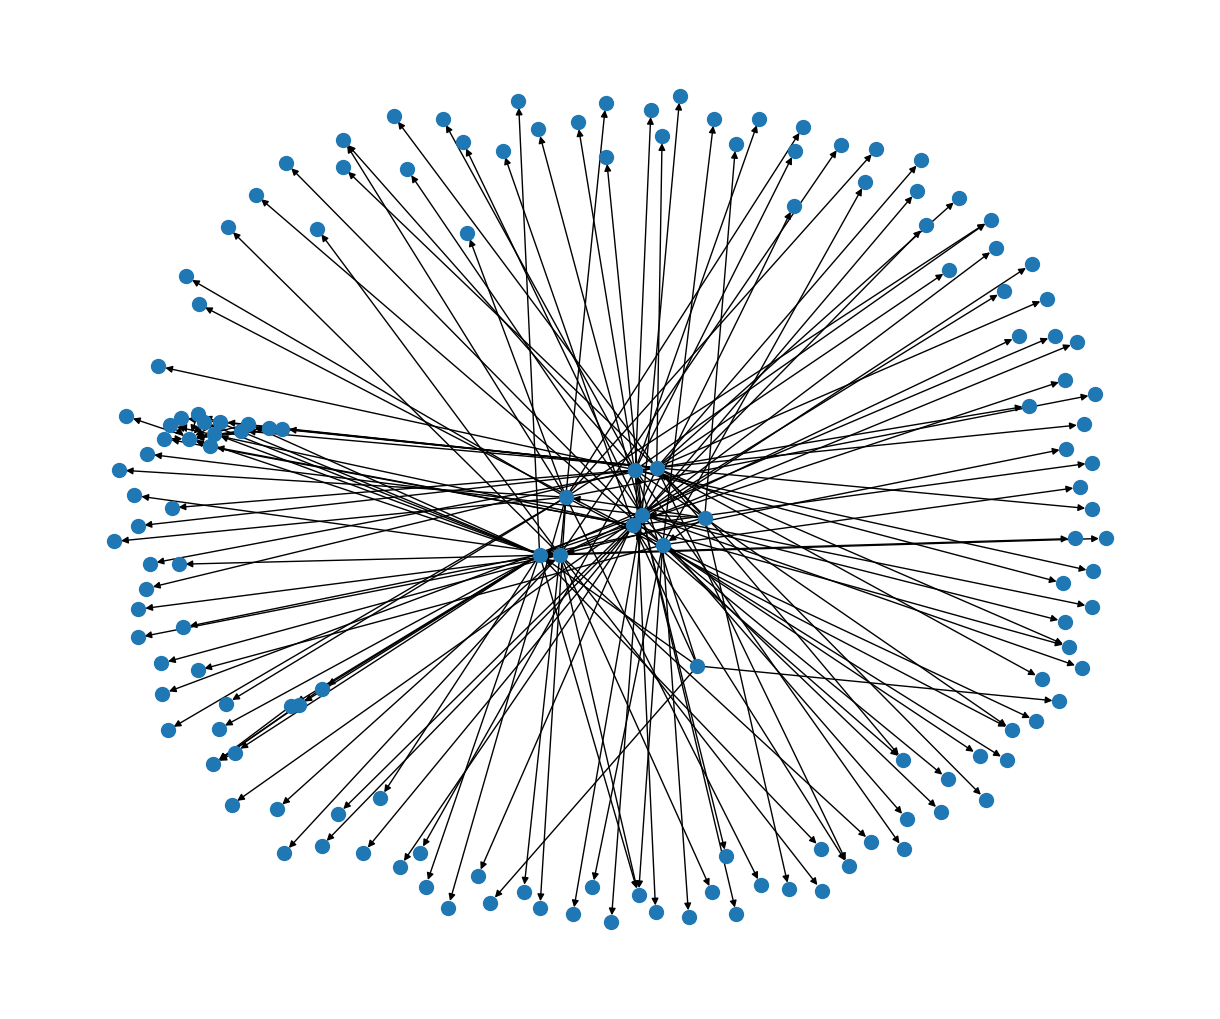

In [57]:
import matplotlib.pyplot as plt

sample = list(
    G.nodes()
)[:150]

H = G.subgraph(sample)

plt.figure(
    figsize=(12, 10)
)

pos = nx.spring_layout(
    H,
    seed=42
)

nx.draw(
    H,
    pos,
    node_size=100,
    with_labels=False
)

plt.show()

Экспорт Neo4j

Узлы

In [58]:
nodes = []

for node, attrs in G.nodes(
    data=True
):

    nodes.append({

        "id": node,

        "type":
            attrs["type"]
    })

nodes_df = pd.DataFrame(
    nodes
)

nodes_df.to_csv(
    "nodes.csv",
    index=False
)

Связи

In [59]:
edges = []

for src, dst, attrs in G.edges(
    data=True
):

    edges.append({

        "source": src,

        "target": dst,

        "relation":
            attrs["rel"]
    })

edges_df = pd.DataFrame(
    edges
)

edges_df.to_csv(
    "edges.csv",
    index=False
)

Статистика

In [60]:
print(
    "Customers:",
    dialogs_df.customer_id.nunique()
)

print(
    "Tickets:",
    dialogs_df.ticket_id.nunique()
)

print(
    "Messages:",
    dialogs_df.message_id.nunique()
)

print(
    "Graph nodes:",
    len(G.nodes())
)

print(
    "Graph edges:",
    len(G.edges())
)

Customers: 85
Tickets: 364
Messages: 2918
Graph nodes: 6328
Graph edges: 8031


In [61]:
print("events_df exists:", "events_df" in globals())
print("dialogs_df exists:", "dialogs_df" in globals())

events_df exists: True
dialogs_df exists: True


In [62]:
events_df.to_csv("events.csv", index=False)
dialogs_df.to_csv("dialogs.csv", index=False)

In [63]:
from google.colab import files
files.download("events.csv")
files.download("dialogs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>